# Carbon Emissions Forecasting - Complete Training Pipeline

This notebook handles the complete ML pipeline:
1. Data loading and exploration
2. Data cleaning and null value handling
3. Data preprocessing and feature engineering
4. Model training (ARIMA, Random Forest, LSTM)
5. Model evaluation and comparison
6. Model persistence (saving to disk)
7. Predictions with saved models

**Output**: Trained models saved to `models/` directory ready for deployment in Streamlit app

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
#gg
#ff
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

## 1. Load and Explore the Dataset

In [2]:
df = pd.read_csv("owid-co2-data-rows-dropped.backup-before-web-refresh.csv")
print("Dataset loaded:", df.shape)

Dataset loaded: (4621, 12)


Columns with missing values: 0


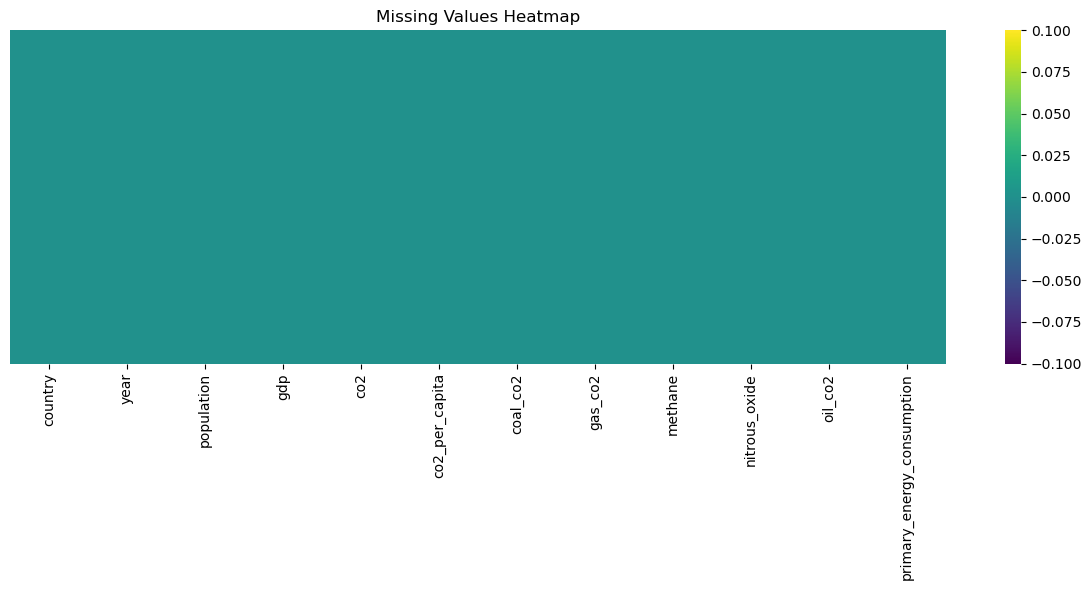

In [3]:
missing_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values
})
print("Columns with missing values:", int((missing_df['Missing_Count'] > 0).sum()))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## 2. Data Cleaning and Null Value Handling

In [4]:
COLUMNS = [
    "country", "year", "population", "gdp", "co2",
    "coal_co2", "oil_co2", "gas_co2", "methane",
    "nitrous_oxide", "primary_energy_consumption"
]

existing_cols = [col for col in COLUMNS if col in df.columns]
df_clean = df[existing_cols].copy()
df_clean = df_clean.sort_values(["country", "year"]).reset_index(drop=True)
df_clean = df_clean.dropna(subset=["co2"])

fill_cols = [col for col in df_clean.columns if col not in ['country', 'year', 'co2']]
for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='ffill')

for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='bfill')

df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (4621, 11)


## 3. Data Preprocessing and Feature Engineering

In [5]:
def remove_outliers(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean = remove_outliers(df_clean, numeric_cols)

def create_lagged_features(data, target_col='co2', lags=3):
    df_lag = data.copy()
    for lag in range(1, lags + 1):
        df_lag[f'{target_col}_lag_{lag}'] = df_lag.groupby('country')[target_col].shift(lag)
    return df_lag

df_features = create_lagged_features(df_clean, target_col='co2', lags=3)
df_features = df_features.dropna()

scaler = StandardScaler()
numeric_features = df_features.select_dtypes(include=[np.number]).columns
df_features[numeric_features] = scaler.fit_transform(df_features[numeric_features])
joblib.dump(scaler, 'models/scaler.pkl')
print("Preprocessed dataset shape:", df_features.shape)

Preprocessed dataset shape: (2776, 14)


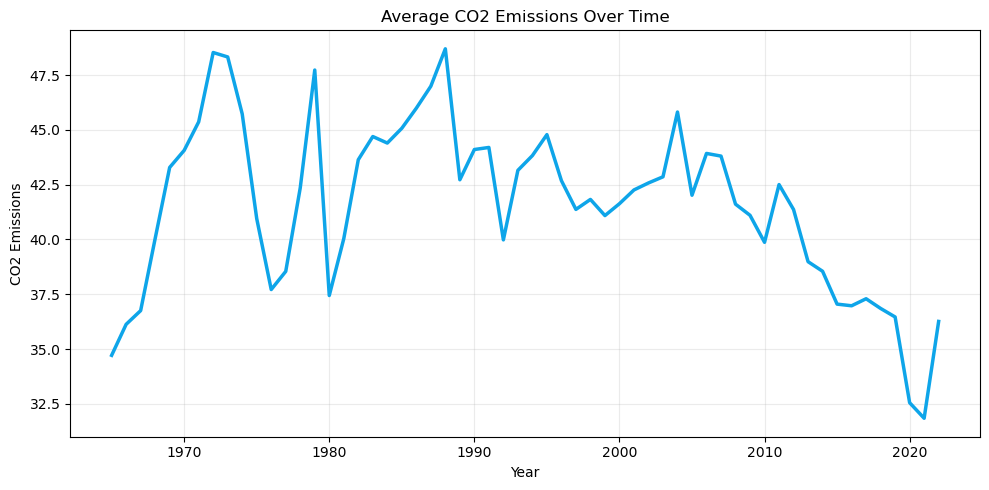

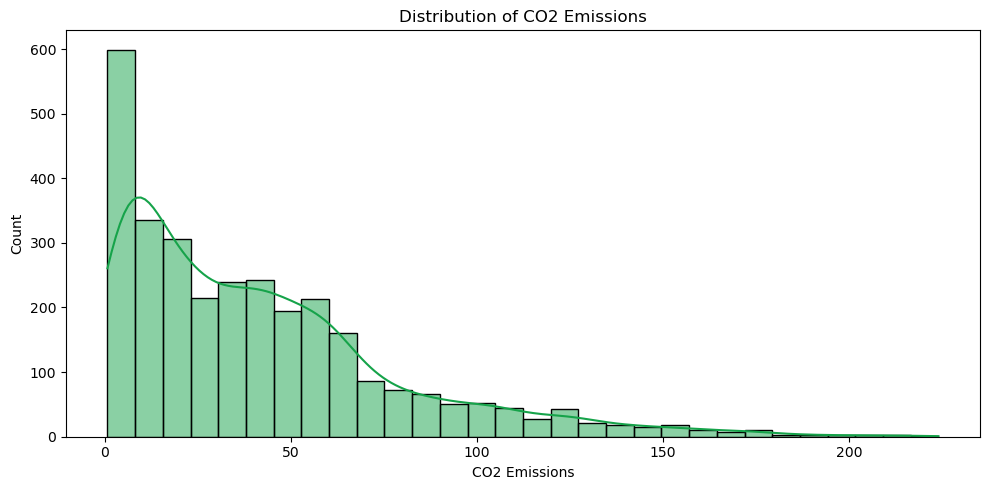

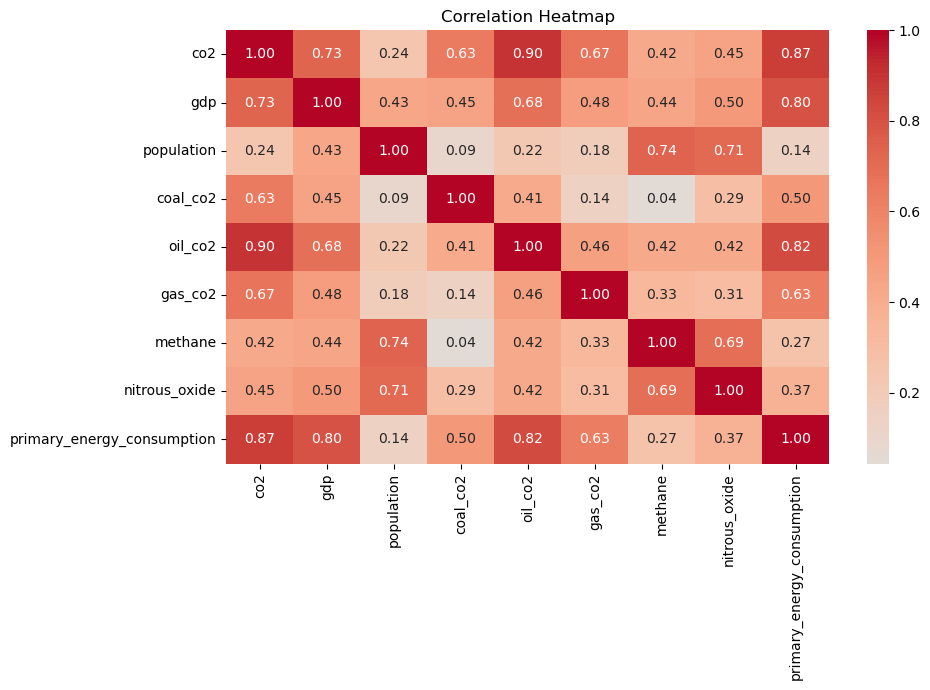

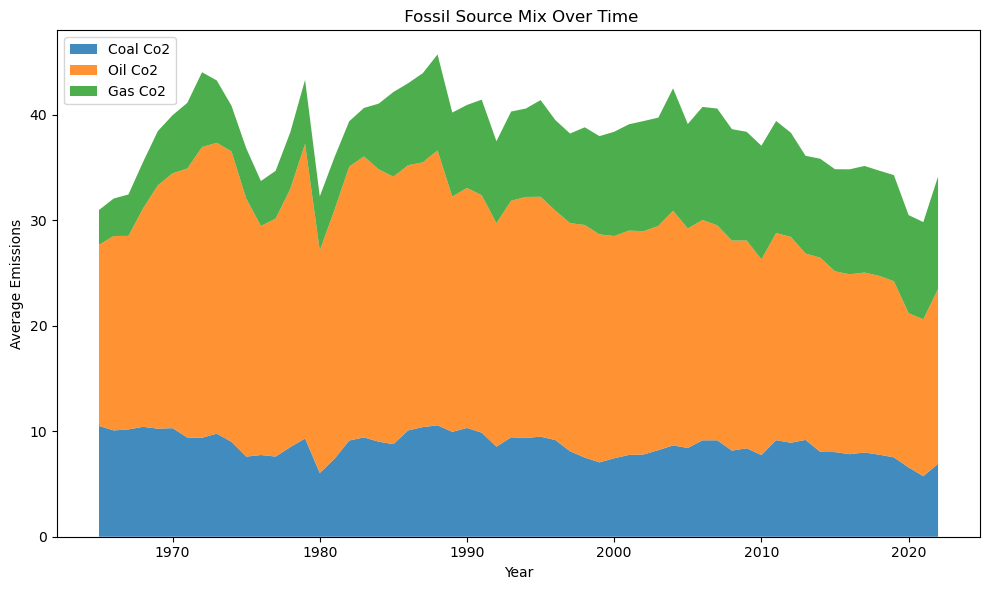

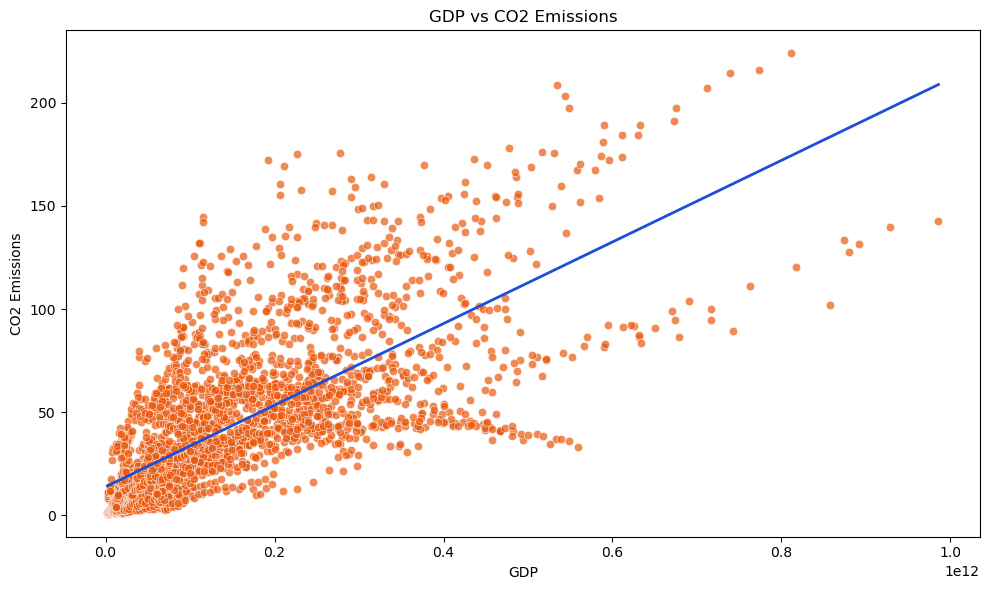

In [6]:
df_viz = df_clean.copy()

co2_year = df_viz.groupby('year', as_index=False)['co2'].mean()
plt.figure(figsize=(10, 5))
plt.plot(co2_year['year'], co2_year['co2'], color='#0ea5e9', linewidth=2.5)
plt.title('Average CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_viz['co2'], bins=30, kde=True, color='#16a34a')
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

num_cols = [c for c in ['co2', 'gdp', 'population', 'coal_co2', 'oil_co2', 'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption'] if c in df_viz.columns]
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 7))
    corr = df_viz[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

mix_cols = [c for c in ['coal_co2', 'oil_co2', 'gas_co2'] if c in df_viz.columns]
if mix_cols:
    mix_year = df_viz.groupby('year', as_index=False)[mix_cols].mean().sort_values('year')
    plt.figure(figsize=(10, 6))
    plt.stackplot(mix_year['year'], *[mix_year[c] for c in mix_cols], labels=[c.replace('_', ' ').title() for c in mix_cols], alpha=0.85)
    plt.title(' Fossil Source Mix Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Emissions')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

if 'gdp' in df_viz.columns and 'co2' in df_viz.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_viz, x='gdp', y='co2', alpha=0.7, color='#ea580c')
    x = df_viz['gdp'].values
    y = df_viz['co2'].values
    if len(df_viz) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        plt.plot(x_sorted, p(x_sorted), color='#1d4ed8', linewidth=2)
    plt.title('GDP vs CO2 Emissions')
    plt.xlabel('GDP')
    plt.ylabel('CO2 Emissions')
    plt.tight_layout()
    plt.show()

## 4. Train Machine Learning Models

Training will be done per-country to capture country-specific patterns. Models will be saved for later use.

In [7]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

model_performance = []

## 5. Model Performance Evaluation and Comparison

In [8]:
pass

In [9]:
MODEL_FEATURE_COLS = [
    'country_encoded', 'year', 'population', 'gdp', 'coal_co2', 'oil_co2',
    'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption'
]

YEAR_WEIGHT = 5.0

df_model = df_clean.copy()
df_model = df_model[['country', 'year', 'co2', 'population', 'gdp', 'coal_co2', 'oil_co2', 'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption']].dropna()

country_names = sorted(df_model['country'].astype(str).unique().tolist())
country_encoding = {name: idx for idx, name in enumerate(country_names)}
df_model['country_encoded'] = df_model['country'].astype(str).map(country_encoding).astype(float)

X = df_model[MODEL_FEATURE_COLS].astype(float).values
y = df_model['co2'].astype(float).values

scaler_regression = StandardScaler()
X_scaled = scaler_regression.fit_transform(X)

year_idx = MODEL_FEATURE_COLS.index('year')
X_scaled[:, year_idx] = X_scaled[:, year_idx] * YEAR_WEIGHT

joblib.dump(scaler_regression, 'models/scaler_regression.pkl')

split_idx = int(len(X_scaled) * 0.8)
X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

X_train_ts = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_ts = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_ts = y_train
y_test_ts = y_test

print("Train/Test samples:", X_train.shape[0], X_test.shape[0])

Train/Test samples: 2448 613


In [10]:
import json

feature_info = {
    'feature_columns': MODEL_FEATURE_COLS,
    'feature_descriptions': {
        'country_encoded': 'Encoded country identifier',
        'year': 'Year of prediction context',
        'population': 'Population (Number of people)',
        'gdp': 'GDP (USD)',
        'coal_co2': 'CO2 from Coal (MT)',
        'oil_co2': 'CO2 from Oil (MT)',
        'gas_co2': 'CO2 from Gas (MT)',
        'methane': 'Methane Emissions (MT)',
        'nitrous_oxide': 'Nitrous Oxide Emissions (MT)',
        'primary_energy_consumption': 'Primary Energy Consumption (EJ)'
    },
    'feature_ranges': {
        col: {
            'min': float(df_model[col].min()),
            'max': float(df_model[col].max()),
            'mean': float(df_model[col].mean())
        }
        for col in MODEL_FEATURE_COLS
    },
    'country_encoding': country_encoding,
    'year_weight': YEAR_WEIGHT,
    'mode': 'lstm_only_country_year'
}

with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

print("Saved models/feature_info.json")

Saved models/feature_info.json


## 8. Deep Learning Models

### Time-Series Models (LSTM + RNN)

In [11]:
pass

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
joblib.dump(rf_model, 'models/random_forest_model.pkl')

if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)
    joblib.dump(xgb_model, 'models/xgboost_model.pkl')

print("Tree-model training completed")

Tree-model training completed


In [13]:
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_ts.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, batch_size=32, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

lstm_pred = lstm_model.predict(X_test_ts, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test_ts, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_ts, lstm_pred))
lstm_r2 = r2_score(y_test_ts, lstm_pred)

lstm_model.save('models/lstm_model.h5')

rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(1, X_train_ts.shape[2])),
    Dropout(0.2),
    SimpleRNN(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_rnn = rnn_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, batch_size=32, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

rnn_pred = rnn_model.predict(X_test_ts, verbose=0).flatten()
rnn_mae = mean_absolute_error(y_test_ts, rnn_pred)
rnn_rmse = np.sqrt(mean_squared_error(y_test_ts, rnn_pred))
rnn_r2 = r2_score(y_test_ts, rnn_pred)

rnn_model.save('models/rnn_model.h5')
print("LSTM and RNN training completed")

LSTM and RNN training completed


Best model: LSTM (R² = 0.9802)


,Model,MAE,RMSE,R² Score,Model Type
0,LSTM,4.705626,6.572663,0.980246,RNN (Time-Series)
1,XGBoost,6.734739,11.396560,0.940609,Boosted Trees
2,Random Forest,7.413506,12.731789,0.925877,Tree Ensemble
3,RNN,7.863626,14.969537,0.897532,RNN (Time-Series)


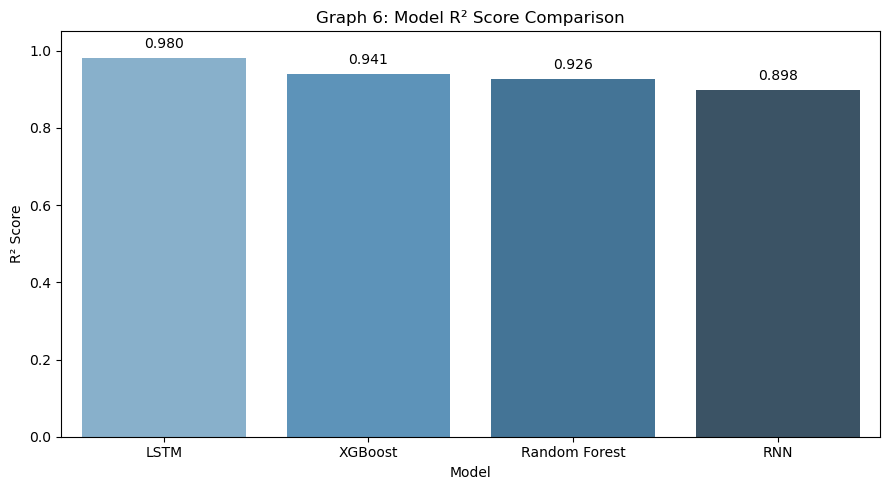

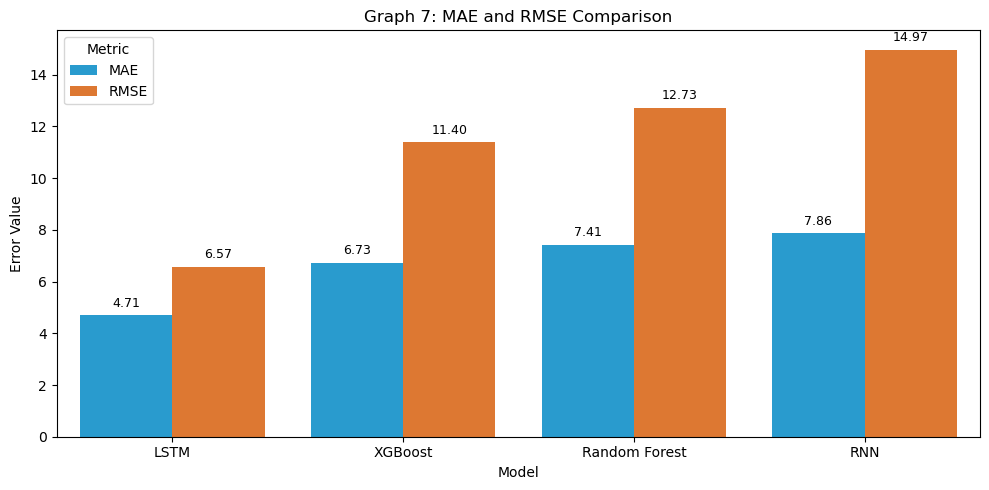

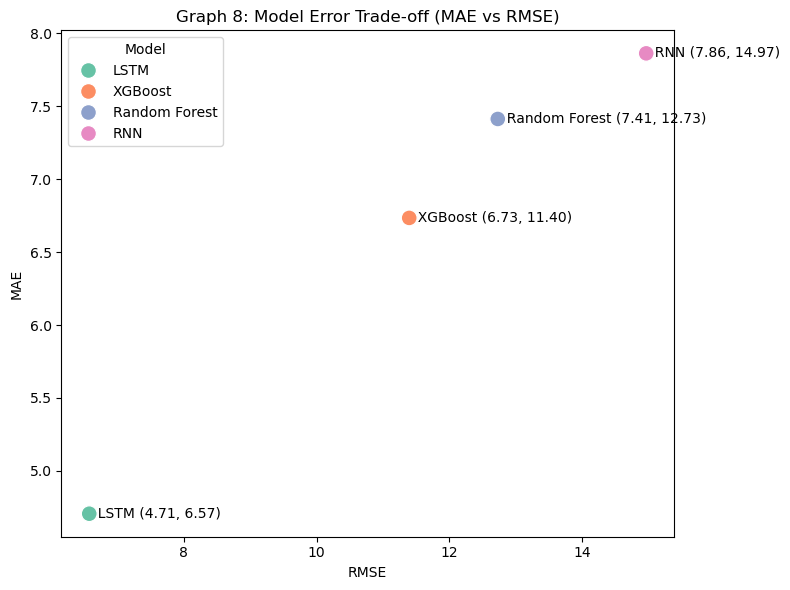

In [14]:
rows = [
    {
        'Model': 'Random Forest',
        'MAE': rf_mae,
        'RMSE': rf_rmse,
        'R² Score': rf_r2,
        'Model Type': 'Tree Ensemble'
    }
]

if 'xgb_mae' in globals() and 'xgb_rmse' in globals() and 'xgb_r2' in globals():
    rows.append(
        {
            'Model': 'XGBoost',
            'MAE': xgb_mae,
            'RMSE': xgb_rmse,
            'R² Score': xgb_r2,
            'Model Type': 'Boosted Trees'
        }
    )

rows.append(
    {
        'Model': 'LSTM',
        'MAE': lstm_mae,
        'RMSE': lstm_rmse,
        'R² Score': lstm_r2,
        'Model Type': 'RNN (Time-Series)'
    }
)

rows.append(
    {
        'Model': 'RNN',
        'MAE': rnn_mae,
        'RMSE': rnn_rmse,
        'R² Score': rnn_r2,
        'Model Type': 'RNN (Time-Series)'
    }
)

all_models_performance = pd.DataFrame(rows).sort_values('R² Score', ascending=False).reset_index(drop=True)
all_models_performance[['Model', 'MAE', 'RMSE', 'R² Score']].to_csv('models/all_models_performance.csv', index=False)

best_row = all_models_performance.iloc[0]
print(f"Best model: {best_row['Model']} (R² = {best_row['R² Score']:.4f})")
display(all_models_performance)

# Graph 6: R² comparison (higher is better)
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=all_models_performance, x='Model', y='R² Score', palette='Blues_d')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f"{height:.3f}",
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=10)
plt.title('Graph 6: Model R² Score Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Graph 7: MAE and RMSE comparison (lower is better)
metrics_long = all_models_performance.melt(
    id_vars='Model',
    value_vars=['MAE', 'RMSE'],
    var_name='Metric',
    value_name='Value'
 )
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metrics_long, x='Model', y='Value', hue='Metric', palette=['#0ea5e9', '#f97316'])
for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height) and height > 1e-6:
        ax.annotate(f"{height:.2f}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha='center', va='bottom', xytext=(0, 4),
                    textcoords='offset points', fontsize=9)
plt.title('Graph 7: MAE and RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('Error Value')
plt.tight_layout()
plt.show()

# Graph 8: MAE vs RMSE trade-off scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(data=all_models_performance, x='RMSE', y='MAE', hue='Model', s=130, palette='Set2')
for _, row in all_models_performance.iterrows():
    plt.text(row['RMSE'], row['MAE'], f"  {row['Model']} ({row['MAE']:.2f}, {row['RMSE']:.2f})", va='center')
plt.title('Graph 8: Model Error Trade-off (MAE vs RMSE)')
plt.xlabel('RMSE')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()